# Concept detection — torch LR na GPU

Wariant 03 z binarną regresją logistyczną zaimplementowaną w PyTorch (LBFGS na GPU) zamiast sklearn. XGBoost bez zmian (już leci na GPU).

Wyniki zapisuje do osobnego katalogu `../data/torch_lr_concepts_detection_results`, żeby nie nadpisywać baseline'u ze sklearn.

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from tqdm.notebook import tqdm
import warnings
import os
import sys
sys.path.append('../../..')

from software.raw_data import get_raw_test_data, get_raw_train_data
from software.torch_lr import TorchLR

In [2]:
def get_metrics(y_true, y_pred, y_prob):
    """Funkcja pomocnicza do obliczania wszystkich metryk."""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0)
    }

In [3]:
NUM_LAYERS = 24
RUNS_PER_LAYER = 10
OUTPUT_DIR = "../../../data/torch_lr_concepts_detection_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

for layer in tqdm(range(NUM_LAYERS), desc="Wszystkie warstwy"):
    layer_results = []

    # Pobieranie danych dla konkretnej warstwy
    train_df = get_raw_train_data(layer)
    test_df = get_raw_test_data(layer)

    X_train_full = train_df.iloc[:, :-1].values
    y_train_full = train_df.iloc[:, -1].astype(int).values

    X_test = test_df.iloc[:, :-1].values
    y_test = test_df.iloc[:, -1].astype(int).values

    # Skalowanie
    scaler = StandardScaler()
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test)

    # Wewnętrzny pasek postępu dla powtórzeń (RUNS)
    run_pbar = tqdm(range(RUNS_PER_LAYER), desc=f" Warstwa {layer:02d}", leave=False)
    for run_id in run_pbar:
        # Bootstrapping ze stratyfikacją (zachowanie proporcji klas)
        X_train_b, y_train_b = resample(
                X_train_full_scaled,
                y_train_full,
                replace=True,
                n_samples=len(y_train_full),
                random_state=run_id,
                stratify=y_train_full
            )

        models = {
            'LogisticRegression': TorchLR(
                C=0.1, max_iter=200, tol=1e-5, device='cuda', random_state=run_id
            ),
            'XGBoost': XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                tree_method='hist', device='cuda',  # <- GPU (RTX 4090)
                random_state=run_id, eval_metric='logloss',
            )
        }

        for model_name, model in models.items():
            model.fit(X_train_b, y_train_b)

            # Predykcje i metryki: TRAIN
            y_train_pred = model.predict(X_train_b)
            y_train_prob = model.predict_proba(X_train_b)[:, 1]
            train_metrics = get_metrics(y_train_b, y_train_pred, y_train_prob)

            # Predykcje i metryki: TEST
            y_test_pred = model.predict(X_test_scaled)
            y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
            test_metrics = get_metrics(y_test, y_test_pred, y_test_prob)

            # Budowa wiersza wynikowego
            row_data = {
                'layer_id': layer,
                'model': model_name,
                'run_id': run_id
            }
            # Dodanie metryk z prefiksami
            row_data.update({f'train_{k}': v for k, v in train_metrics.items()})
            row_data.update({f'test_{k}': v for k, v in test_metrics.items()})

            layer_results.append(row_data)

    # Zapis do CSV po każdej warstwie (bezpieczeństwo)
    df_layer = pd.DataFrame(layer_results)
    filename = f"{layer:02d}_torch_lr_concept_detection.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df_layer.to_csv(filepath, index=False)


Wszystkie warstwy:   0%|          | 0/24 [00:00<?, ?it/s]

 Warstwa 00:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 01:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 02:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 03:   0%|          | 0/10 [00:00<?, ?it/s]

...

 Warstwa 19:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 20:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 21:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 22:   0%|          | 0/10 [00:00<?, ?it/s]

 Warstwa 23:   0%|          | 0/10 [00:00<?, ?it/s]

# Visualization

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

In [6]:
OUTPUT_DIR = "../../../data/torch_lr_concepts_detection_results"
all_files = glob.glob(os.path.join(OUTPUT_DIR, "*_torch_lr_concept_detection.csv"))

In [7]:
li = []
for filename in all_files:
    df = pd.read_csv(filename)
    li.append(df)

In [8]:
df_all = pd.concat(li, axis=0, ignore_index=True).sort_values('layer_id')

In [9]:
df_all.head(1)

,layer_id,model,run_id,train_accuracy,train_roc_auc,train_f1,train_recall,train_precision,test_accuracy,test_roc_auc,test_f1,test_recall,test_precision
460,0,LogisticRegression,0,0.873326,0.94317,0.874655,0.883929,0.865574,0.632812,0.687683,0.629921,0.625,0.634921


In [10]:
metric_cols = [c for c in df_all.columns if 'train_' in c or 'test_' in c]
metric_cols = [col for col in metric_cols if col.split('_')[1] not in ['recall', 'precision']]
id_vars = ['layer_id', 'model', 'run_id']

In [11]:
df_melted = df_all.melt(id_vars=id_vars, value_vars=metric_cols, 
                        var_name='metric_type', value_name='score')

# Rozdzielamy informacje o zbiorze (train/test) i nazwie metryki
df_melted['subset'] = df_melted['metric_type'].apply(lambda x: x.split('_')[0])
df_melted['metric'] = df_melted['metric_type'].apply(lambda x: x.split('_')[1])

In [12]:
from warnings import filterwarnings

filterwarnings('ignore')

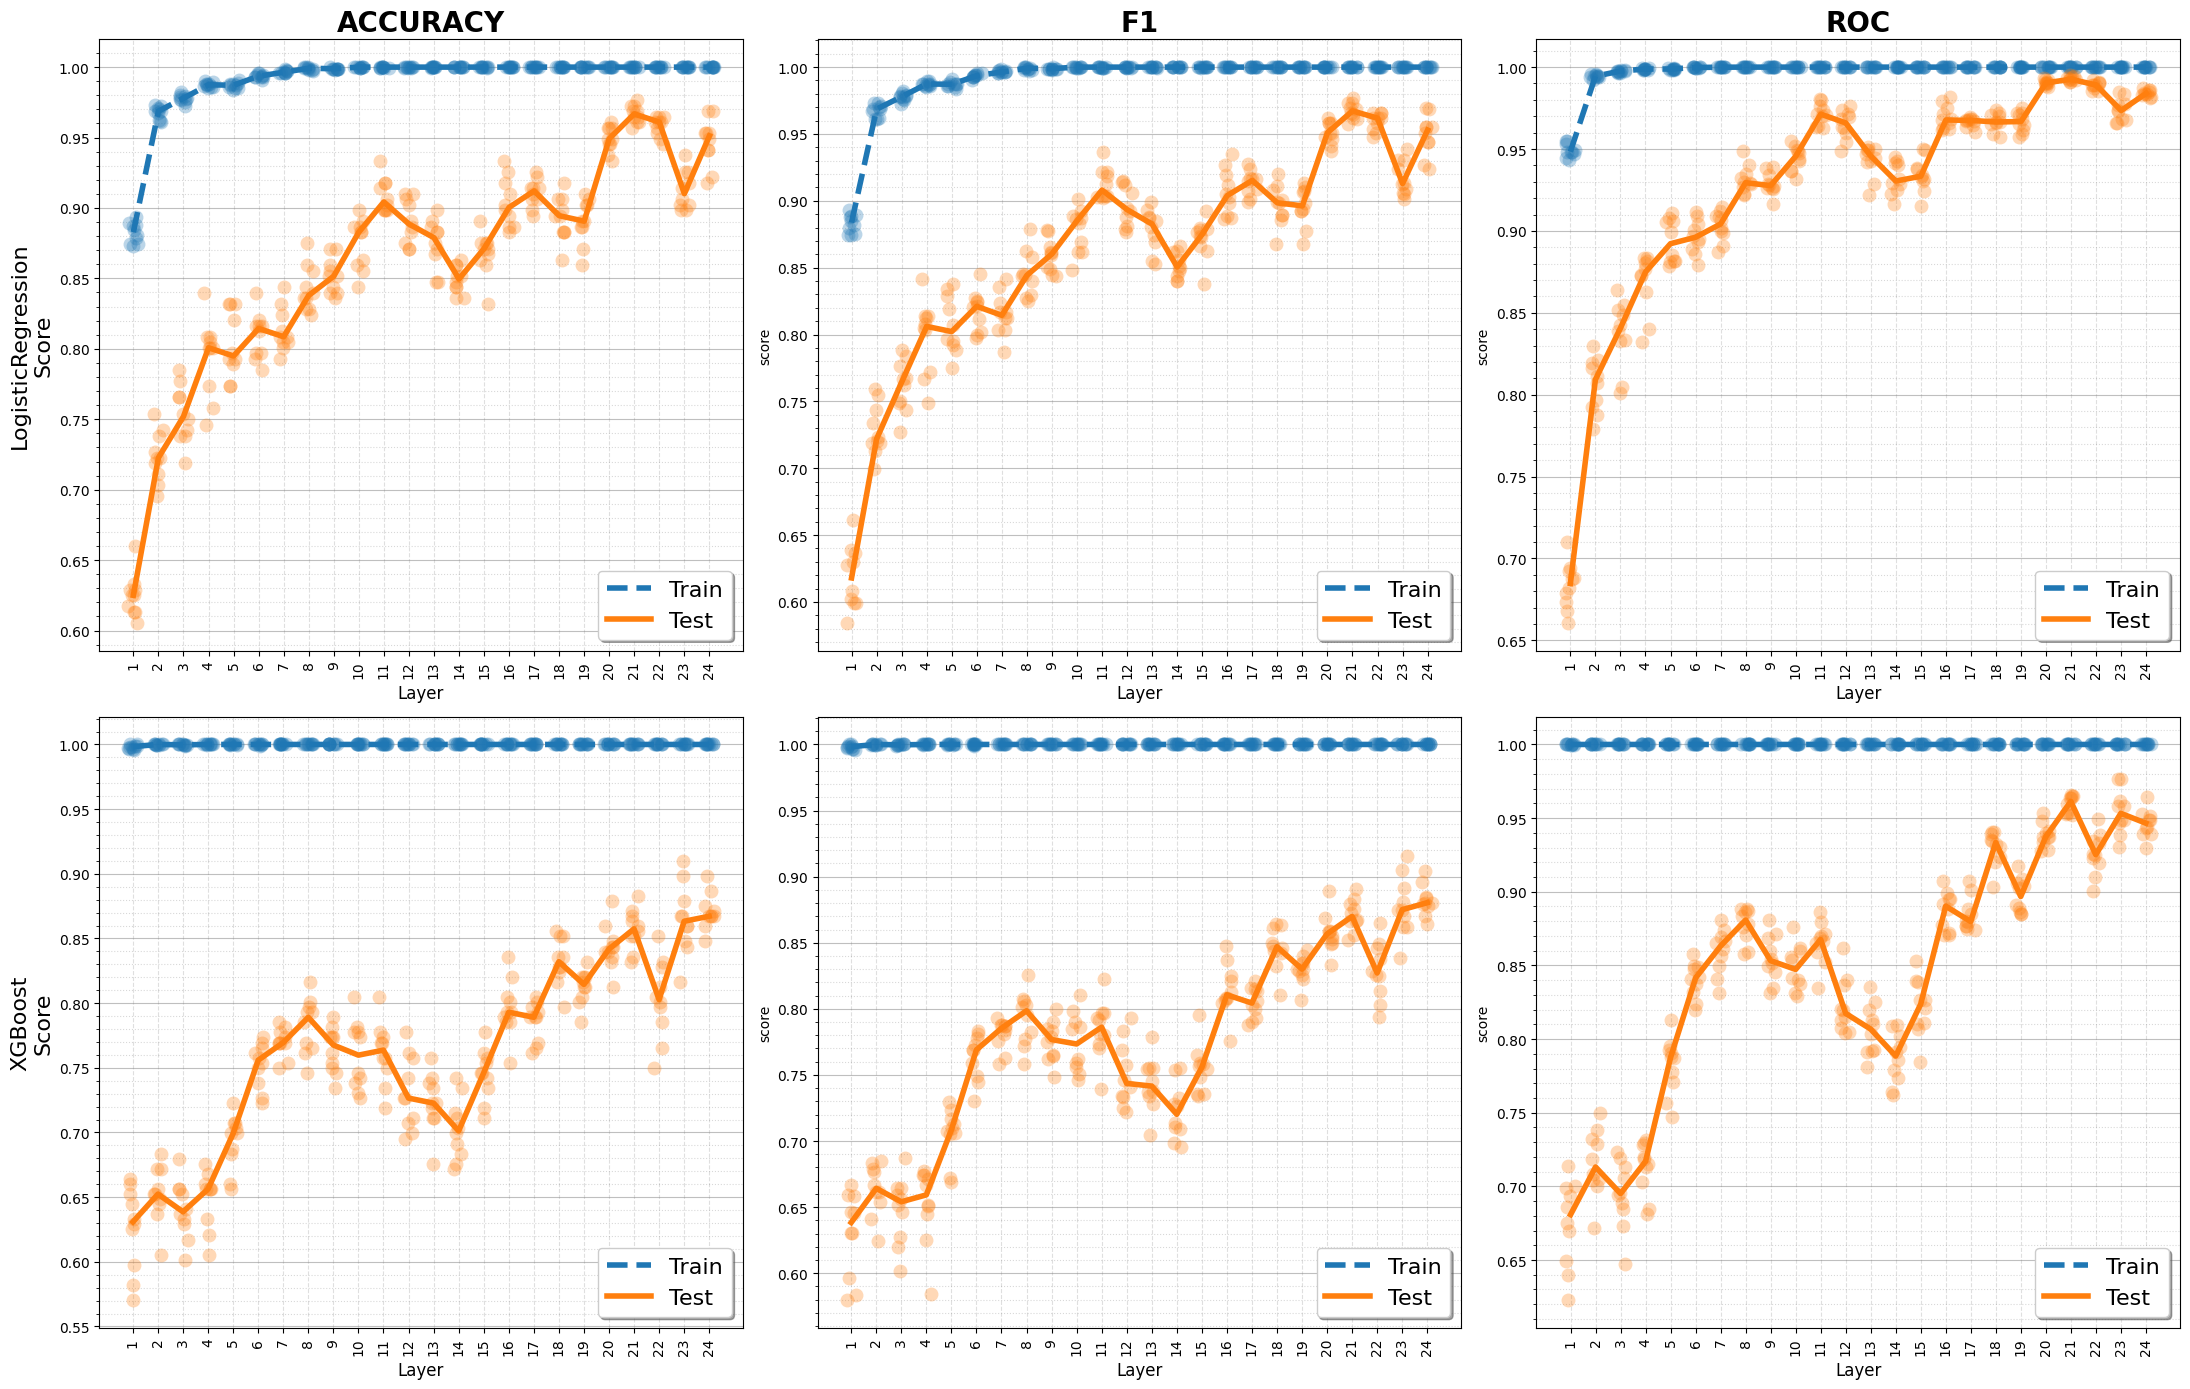

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

models = sorted(df_melted['model'].unique())      # ['LogisticRegression', 'XGBoost']
metrics = sorted(df_melted['metric'].unique())    # ['accuracy', 'f1', 'roc_auc']
colors = {'train': '#1f77b4', 'test': '#ff7f0e'}  # niebieski / pomarańczowy

# Upewniamy się, że używamy oryginalnego layer_id (0-23)
df_plot = df_melted.copy()

# Usunięto sharex=True, aby każda miniatura miała własne podpisy warstw
fig, axes = plt.subplots(len(models), len(metrics), figsize=(22, 7 * len(models)))
if len(models) == 1: axes = np.expand_dims(axes, axis=0)

for r, model in enumerate(models):
    for c, metric in enumerate(metrics):
        ax = axes[r, c]

        layer_indices = sorted(df_plot['layer_id'].unique())

        for subset in ['train', 'test']:
            data = df_plot[(df_plot['model'] == model) &
                           (df_plot['metric'] == metric) &
                           (df_plot['subset'] == subset)]

            # Rysujemy punkty
            sns.stripplot(data=data, x='layer_id', y='score', color=colors[subset],
                          alpha=0.3, jitter=0.2, size=10, ax=ax)

            # Rysujemy medianę
            sns.lineplot(data=data, x='layer_id', y='score', color=colors[subset],
                         estimator=np.median, errorbar=None, linewidth=4, ax=ax,
                         linestyle='--' if subset == 'train' else '-')

        # --- PODPISY WARSTW DLA KAŻDEGO WYKRESU ---
        ax.set_xticks(layer_indices)
        ax.set_xticklabels([str(i + 1) for i in layer_indices], rotation=90)
        ax.set_xlabel("Layer", fontsize=12)

        # --- OŚ OY (Papier milimetrowy) ---
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
        ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.5, color='gray')
        ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.3, color='gray')

        # Pionowa siatka dla warstw
        ax.grid(True, axis='x', linestyle='--', alpha=0.4)

        # --- POWIĘKSZONA LEGENDA ---
        h = [plt.Line2D([0], [0], color=colors['train'], lw=4, linestyle='--'),
             plt.Line2D([0], [0], color=colors['test'], lw=4, linestyle='-')]

        ax.legend(h, ['Train', 'Test'],
                  loc='lower right',
                  frameon=True,
                  shadow=True,
                  prop={'size': 16})

        if r == 0: ax.set_title(metric.upper(), fontsize=20, fontweight='bold')
        if c == 0: ax.set_ylabel(f"{model}\nScore", fontsize=16)

plt.tight_layout()
plt.savefig('plots/eyeglasses_concept_detection_torch.png', bbox_inches='tight')
plt.show()